# 01 ? Univariate Analysis (Processed Data)

This notebook visualizes key variables from the processed feature tables:
- `orders_features.csv`
- `customer_features.csv`
- `restaurant_features.csv`
- `cuisine_features.csv`

Note: If `*.new.csv` versions exist (written when the original CSVs are locked by Excel), this notebook will automatically load those instead.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

In [4]:
def resolve_processed_path(stem: str) -> Path:
    base = Path("data/processed")
    new_path = base / f"{stem}.new.csv"
    return new_path
    ##old_path = base / f"{stem}.csv"
    ##return new_path if new_path.exists() else old_path

orders_path = resolve_processed_path("orders_features")
customers_path = resolve_processed_path("customer_features")
restaurants_path = resolve_processed_path("restaurant_features")
cuisines_path = resolve_processed_path("cuisine_features")

orders = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\orders_features.new.csv")
customers = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\customer_features.new.csv")
restaurants = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\restaurant_features.new.csv")
cuisines = pd.read_csv(r"C:\Users\dnune\OneDrive\Desktop\WEEK_2.0_PROJECT\data\processed\cuisine_features.new.csv")

orders_path, customers_path, restaurants_path, cuisines_path

(WindowsPath('data/processed/orders_features.new.csv'),
 WindowsPath('data/processed/customer_features.new.csv'),
 WindowsPath('data/processed/restaurant_features.new.csv'),
 WindowsPath('data/processed/cuisine_features.new.csv'))

In [5]:
def missingness_report(df: pd.DataFrame, name: str, top_n: int = 15) -> pd.DataFrame:
    miss = df.isna().mean().mul(100).sort_values(ascending=False)
    miss = miss[miss > 0]
    if miss.empty:
        print(f"{name}: no missing values")
        return miss.to_frame("missing_%")
    print(f"{name}: missing values (%), top {min(top_n, len(miss))}")
    display(miss.head(top_n).to_frame("missing_%").round(3))
    return miss.to_frame("missing_%")

missingness_report(orders, "orders")
missingness_report(customers, "customers")
missingness_report(restaurants, "restaurants")
missingness_report(cuisines, "cuisines")

orders: missing values (%), top 3


,missing_%
top_rating_flag,38.778
high_rating_flag,38.778
rating_num,38.778


customers: missing values (%), top 9


,missing_%
std_prep_time,65.333
std_cost,65.333
std_delivery_time,65.333
std_total_fulfillment_time,65.333
delivery_time_cv,65.333
total_time_cv,65.333
avg_rating,28.417
pct_high_rating,28.417
pct_top_rating,28.417


restaurants: missing values (%), top 5


,missing_%
delivery_time_cv,28.09
std_delivery_time,28.09
pct_high_rating,12.36
avg_rating,12.36
pct_top_rating,12.36


cuisines: no missing values


,missing_%


## Orders (order-level)

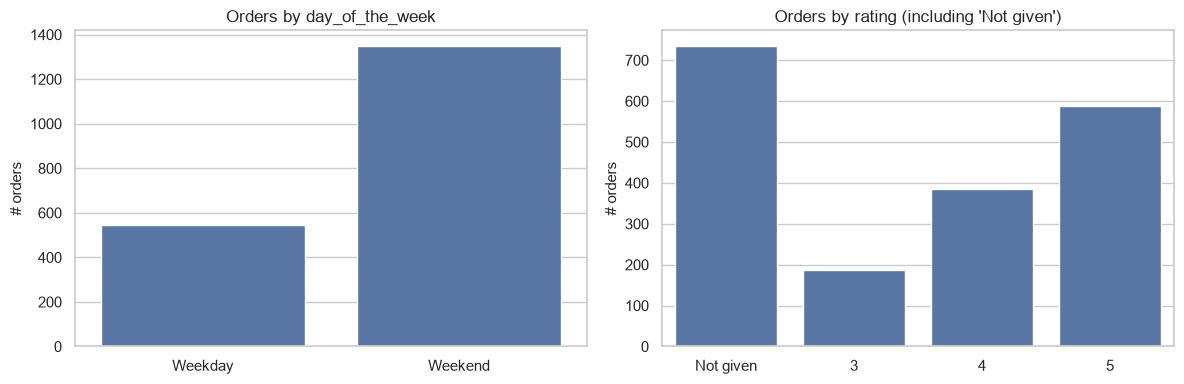

In [6]:
# Categorical distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=orders, x="day_of_the_week", order=["Weekday", "Weekend"], ax=axes[0])
axes[0].set_title("Orders by day_of_the_week")
axes[0].set_xlabel("")
axes[0].set_ylabel("# orders")

sns.countplot(data=orders, x="rating", order=["Not given", "3", "4", "5"], ax=axes[1])
axes[1].set_title("Orders by rating (including 'Not given')")
axes[1].set_xlabel("")
axes[1].set_ylabel("# orders")

plt.tight_layout()
plt.show()

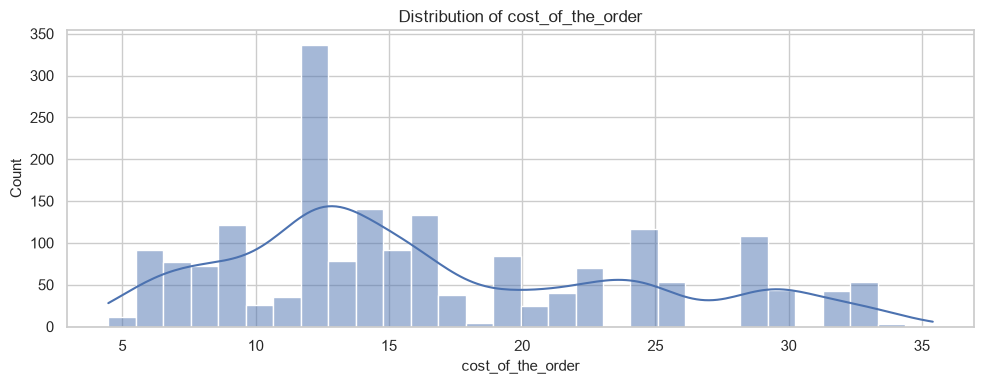

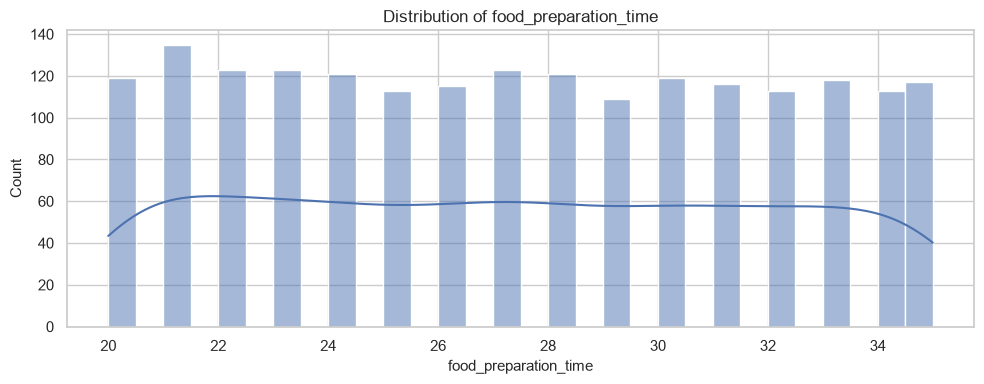

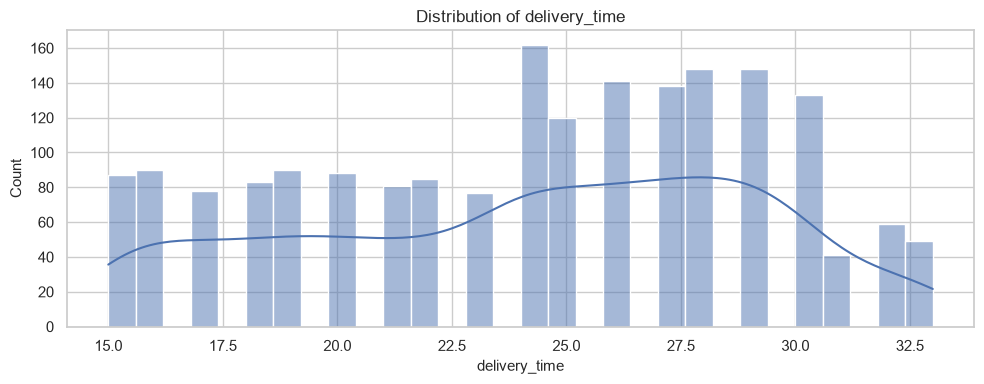

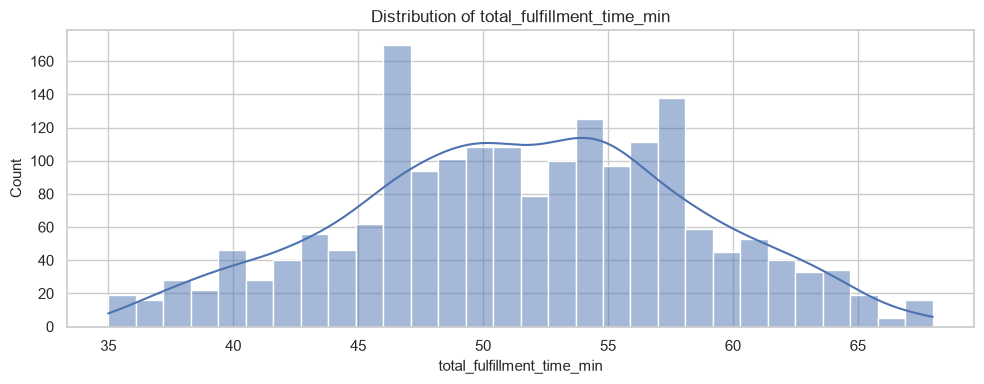

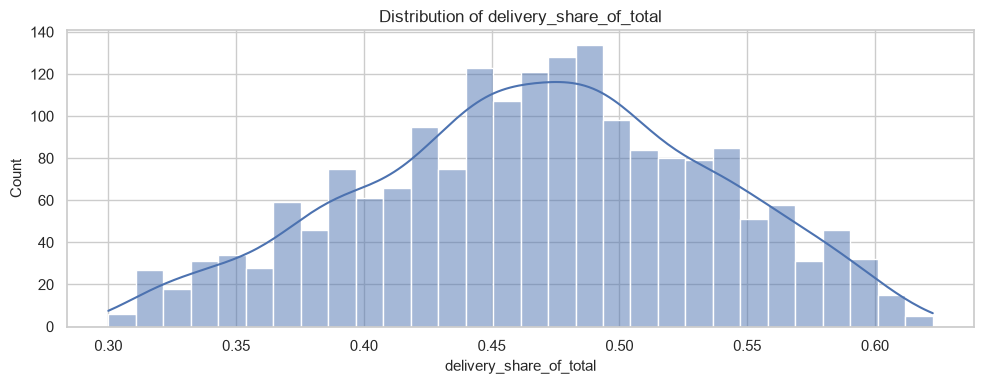

In [7]:
# Numeric distributions
num_cols = [
    "cost_of_the_order",
    "food_preparation_time",
    "delivery_time",
    "total_fulfillment_time_min",
    "delivery_share_of_total",
]

for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=orders, x=col, kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

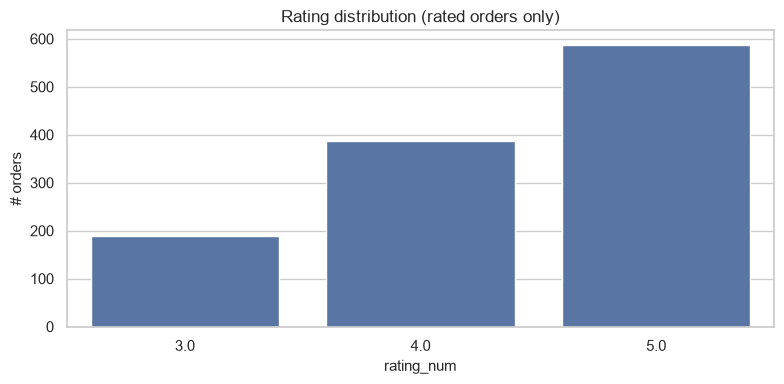

In [13]:
# Rating distribution among rated orders only
rated = orders.loc[orders["rated_flag"] == True].copy()

plt.figure(figsize=(8, 4))
sns.countplot(data=rated, x="rating_num", order=sorted(rated["rating_num"].dropna().unique()))
plt.title("Rating distribution (rated orders only)")
plt.xlabel("rating_num")
plt.ylabel("# orders")
plt.tight_layout()
plt.show()

## Customers (customer-level)

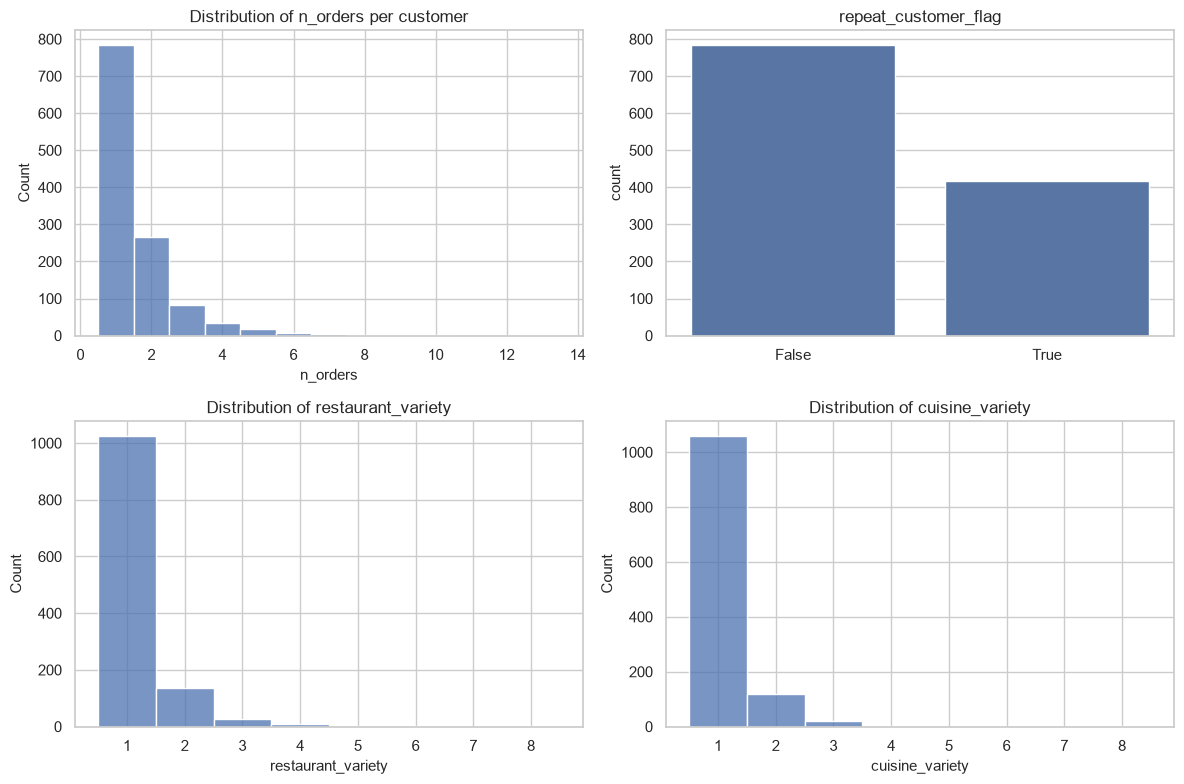

In [14]:
# Key engagement and variety distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=customers, x="n_orders", discrete=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of n_orders per customer")

sns.countplot(data=customers, x="repeat_customer_flag", ax=axes[0, 1])
axes[0, 1].set_title("repeat_customer_flag")
axes[0, 1].set_xlabel("")

sns.histplot(data=customers, x="restaurant_variety", discrete=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of restaurant_variety")

sns.histplot(data=customers, x="cuisine_variety", discrete=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of cuisine_variety")

plt.tight_layout()
plt.show()

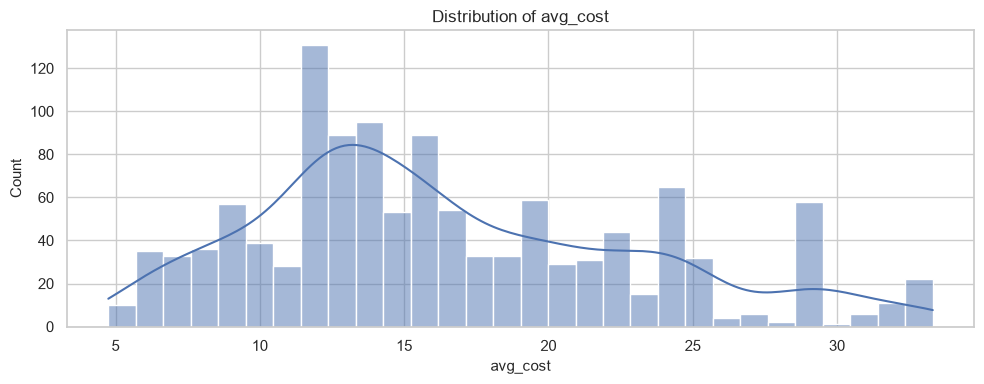

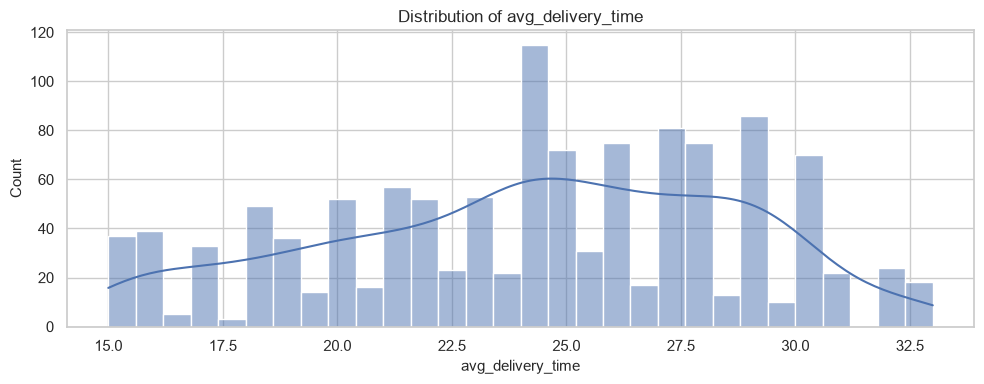

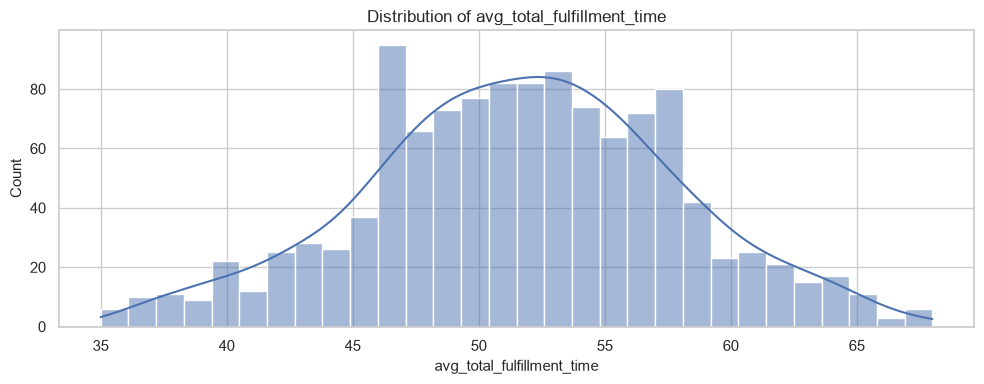

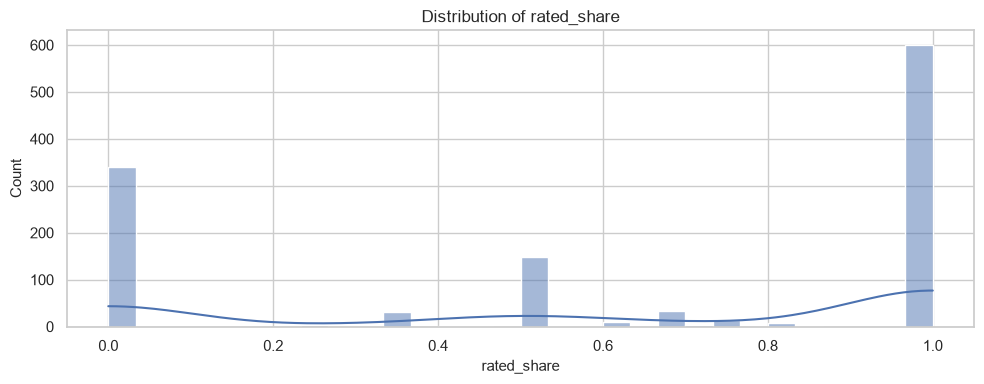

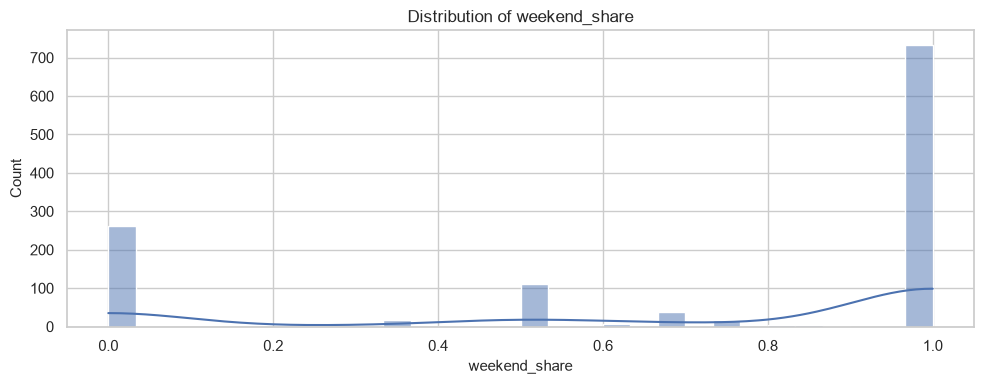

In [15]:
# Customer experience proxies
cols = ["avg_cost", "avg_delivery_time", "avg_total_fulfillment_time", "rated_share", "weekend_share"]

for col in cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=customers, x=col, kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

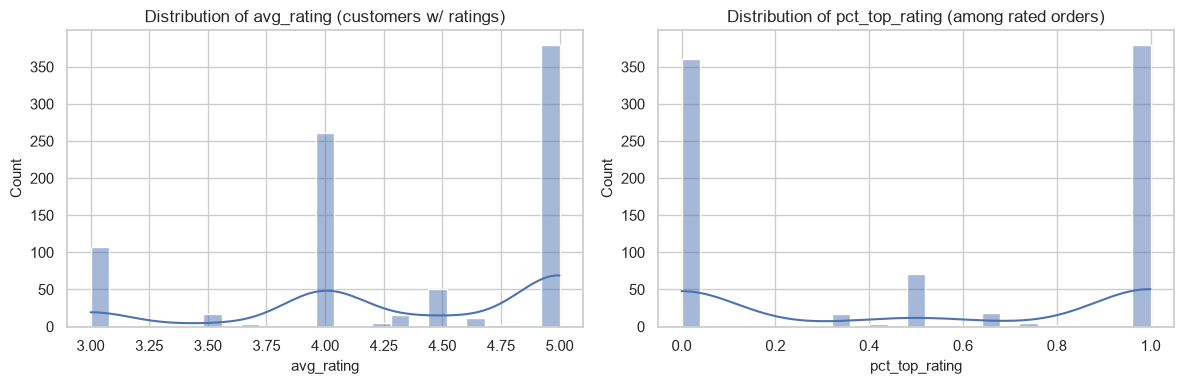

In [16]:
# Rating summaries for customers with at least one rated order
if "has_rated_orders" in customers.columns:
    cust_rated = customers.loc[customers["has_rated_orders"] == True].copy()
else:
    cust_rated = customers.loc[customers["rated_share"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=cust_rated, x="avg_rating", kde=True, bins=25, ax=axes[0])
axes[0].set_title("Distribution of avg_rating (customers w/ ratings)")

sns.histplot(data=cust_rated, x="pct_top_rating", kde=True, bins=25, ax=axes[1])
axes[1].set_title("Distribution of pct_top_rating (among rated orders)")

plt.tight_layout()
plt.show()

## Restaurants (restaurant-level)

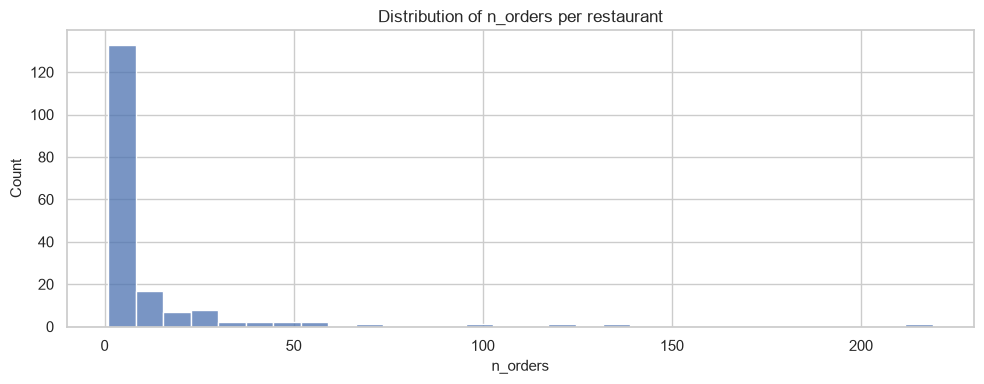

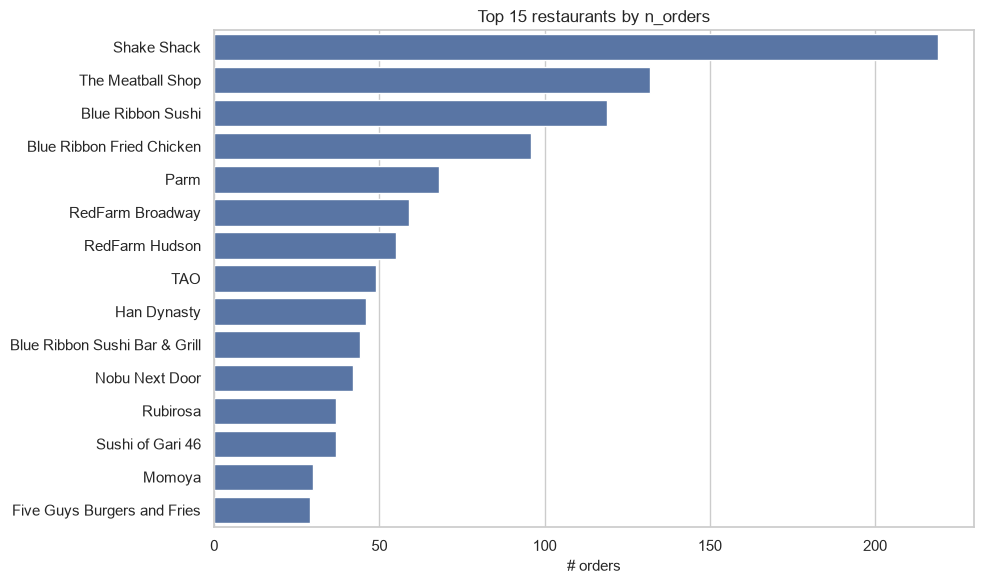

In [17]:
# Restaurant volume
plt.figure(figsize=(10, 4))
sns.histplot(data=restaurants, x="n_orders", bins=30)
plt.title("Distribution of n_orders per restaurant")
plt.tight_layout()
plt.show()

# Top restaurants by order count
top_restaurants = restaurants.sort_values("n_orders", ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_restaurants, y="restaurant_name", x="n_orders")
plt.title("Top 15 restaurants by n_orders")
plt.xlabel("# orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

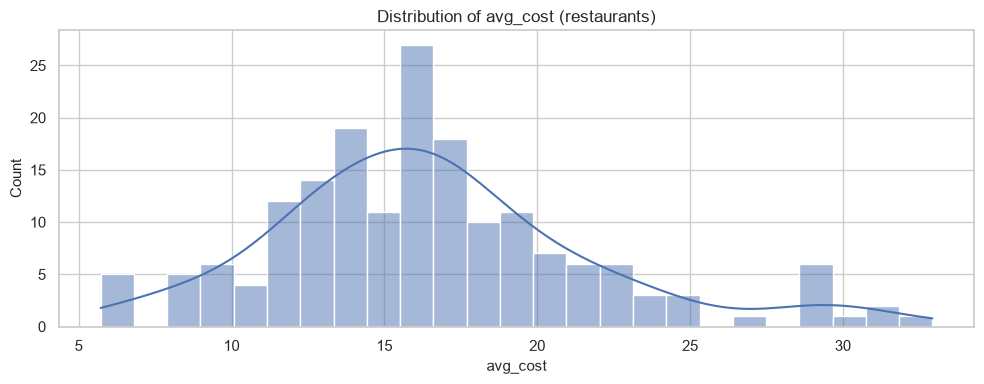

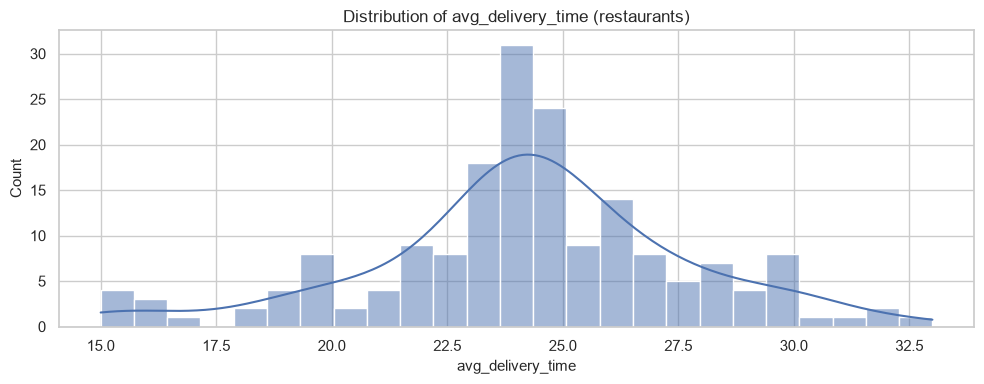

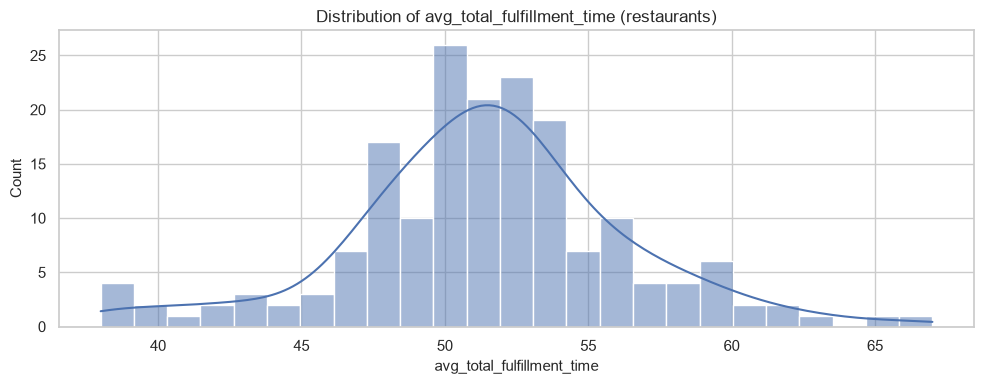

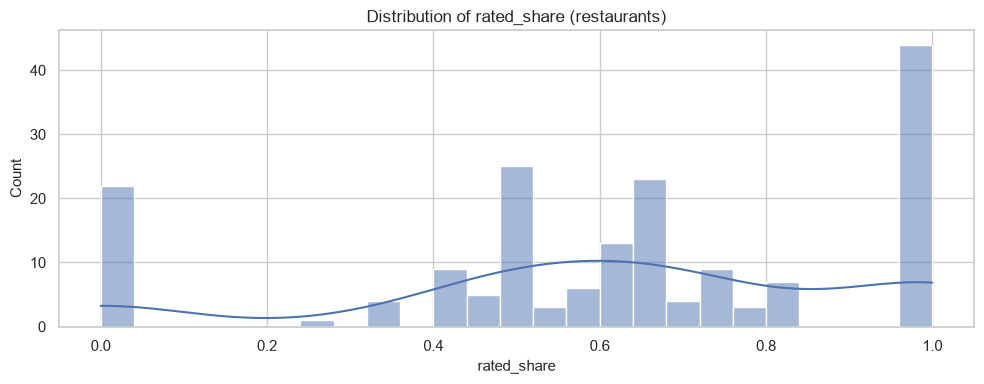

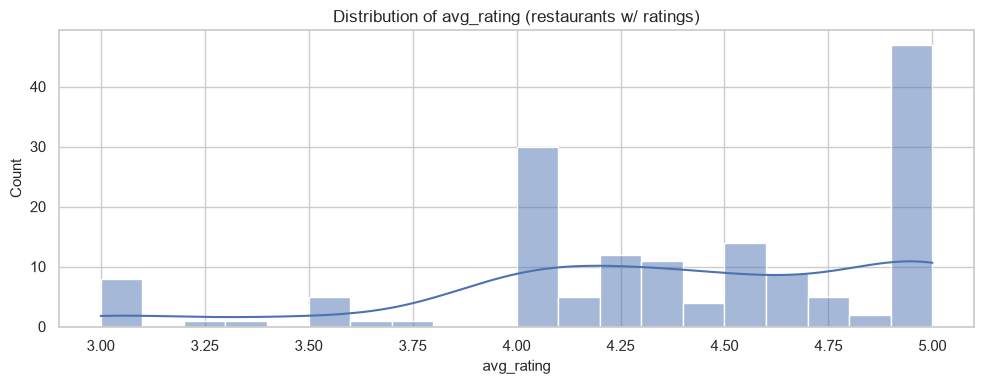

In [18]:
# Restaurant experience proxies
cols = ["avg_cost", "avg_delivery_time", "avg_total_fulfillment_time", "rated_share"]

for col in cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=restaurants, x=col, kde=True, bins=25)
    plt.title(f"Distribution of {col} (restaurants)")
    plt.tight_layout()
    plt.show()

if "has_rated_orders" in restaurants.columns:
    rest_rated = restaurants.loc[restaurants["has_rated_orders"] == True].copy()
else:
    rest_rated = restaurants.loc[restaurants["rated_share"] > 0].copy()

plt.figure(figsize=(10, 4))
sns.histplot(data=rest_rated, x="avg_rating", kde=True, bins=20)
plt.title("Distribution of avg_rating (restaurants w/ ratings)")
plt.tight_layout()
plt.show()

## Cuisines (cuisine-level)

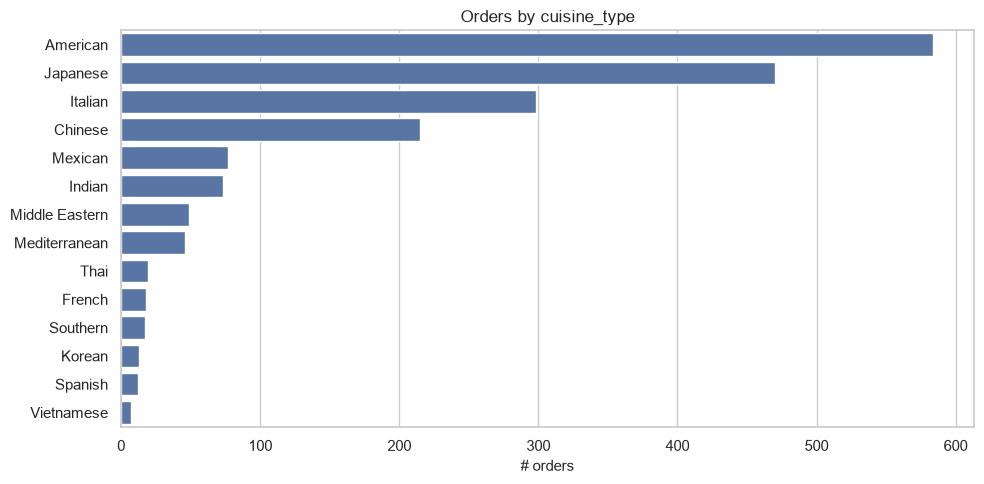

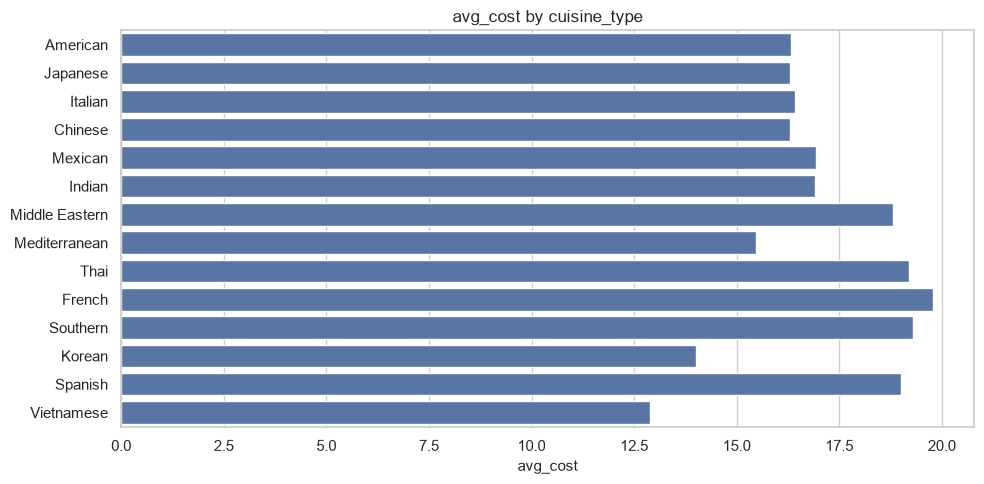

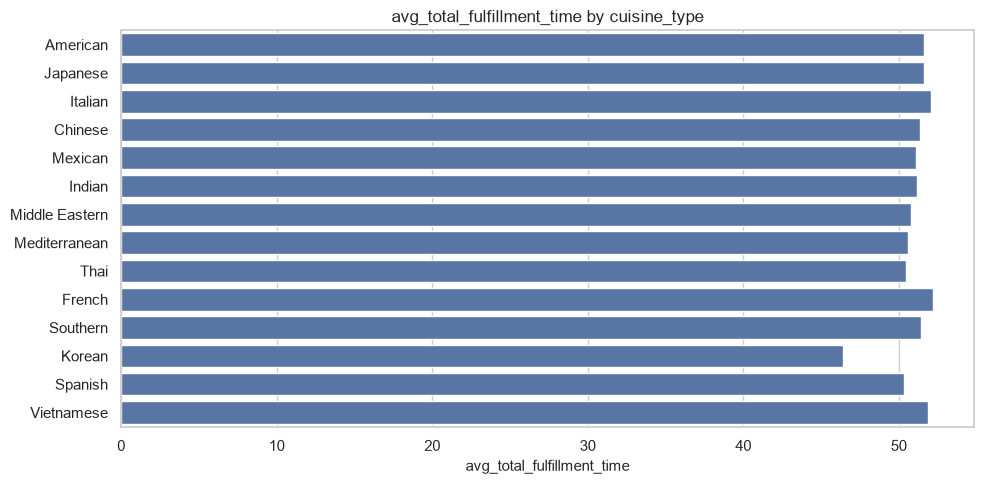

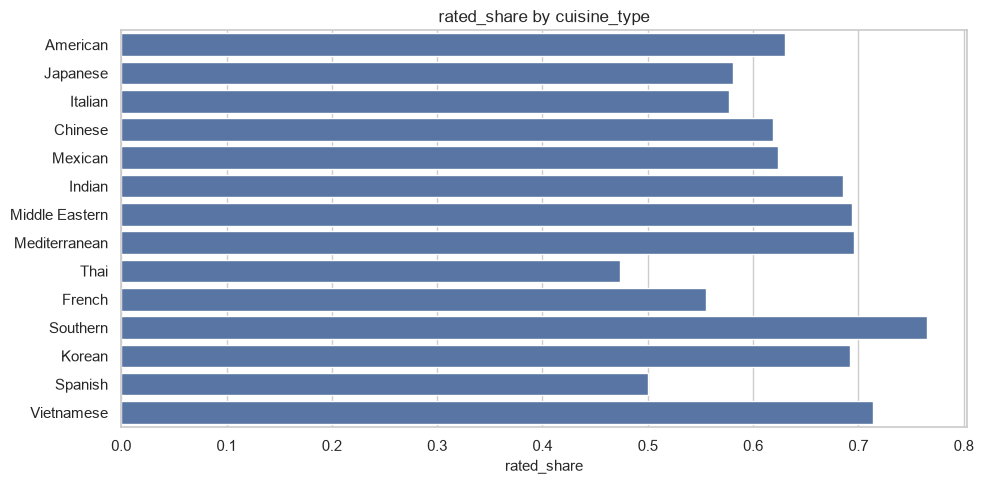

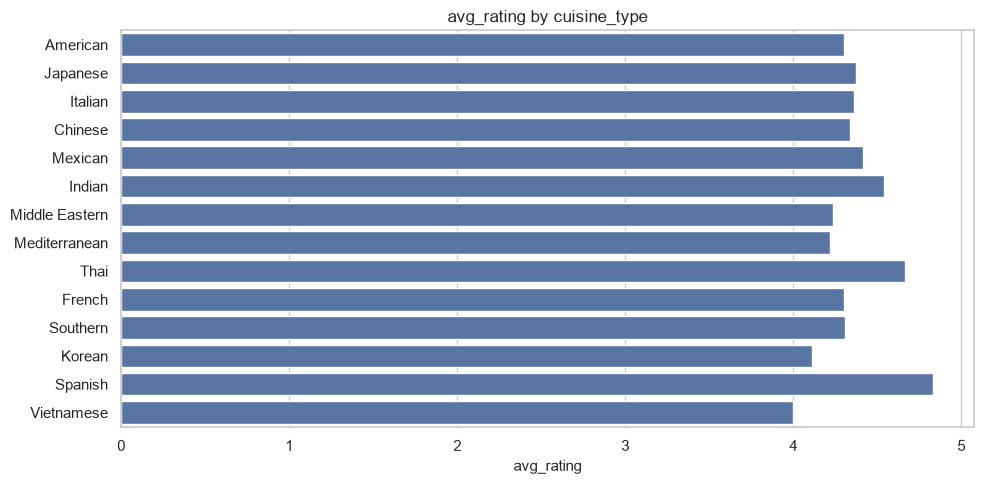

In [19]:
# Cuisine distribution by number of orders
plt.figure(figsize=(10, 5))
ordered = cuisines.sort_values("n_orders", ascending=False)
sns.barplot(data=ordered, y="cuisine_type", x="n_orders")
plt.title("Orders by cuisine_type")
plt.xlabel("# orders")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Distributions across cuisines (small N=14, so barplots are clearer)
for col in ["avg_cost", "avg_total_fulfillment_time", "rated_share", "avg_rating"]:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=ordered, y="cuisine_type", x=col)
    plt.title(f"{col} by cuisine_type")
    plt.xlabel(col)
    plt.ylabel("")
    plt.tight_layout()
    plt.show()